In [64]:
import csv
import shutil
from pathlib import Path
import numpy as np
from PIL import Image
import csv as _csv
import pandas as pd


BASE     = Path("/Users/mariasilva/data/urban-mosaic/washington-square")
CSV_PATH = Path("/Users/mariasilva/data/urban-mosaic/washington-square.csv")
OUT_DIR  = Path("night")

OUT_DIR.mkdir(exist_ok=True)

In [65]:
with open(CSV_PATH) as f:
    print({row["period"] for row in csv.DictReader(f)})

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mariasilva/data/urban-mosaic/washington-square.csv'

In [ ]:
df = pd.read_csv(CSV_PATH)
df["period"].value_counts()

period
morning      65554
afternoon    34692
evening        349
Name: count, dtype: int64

In [71]:
import json
import pandas as pd
from pathlib import Path

results_df = pd.read_csv("all_brightness.csv")
darkest = results_df.sort_values("grey").head(1000)

rows_json = json.dumps([
    {
        "image":    f"urban-mosaic/washington-square/{row['image']}",
        "grey":     row["grey"],
        "period":   row["period"],
        "hour":     int(row["hour"]) if pd.notna(row["hour"]) else "?",
        "taken_on": row["taken_on_short"] if pd.notna(row.get("taken_on_short", None)) else "",
    }
    for _, row in darkest.iterrows()
])

html = open("darkest_viewer.html").read()

# Find and replace the data array in the existing viewer
import re
html = re.sub(r'const data = \[.*?\];', f'const data = {rows_json};', html, flags=re.DOTALL)

Path("darkest_viewer.html").write_text(html)
print("Viewer updated!")

Viewer updated!


In [46]:
df["hour"].value_counts().sort_index()

hour
7       606
8     11125
9     13884
10    10954
11    13890
12    15095
13    10262
14     7802
15     9308
16     5472
17     1197
18      651
19      136
20       14
22      199
Name: count, dtype: int64

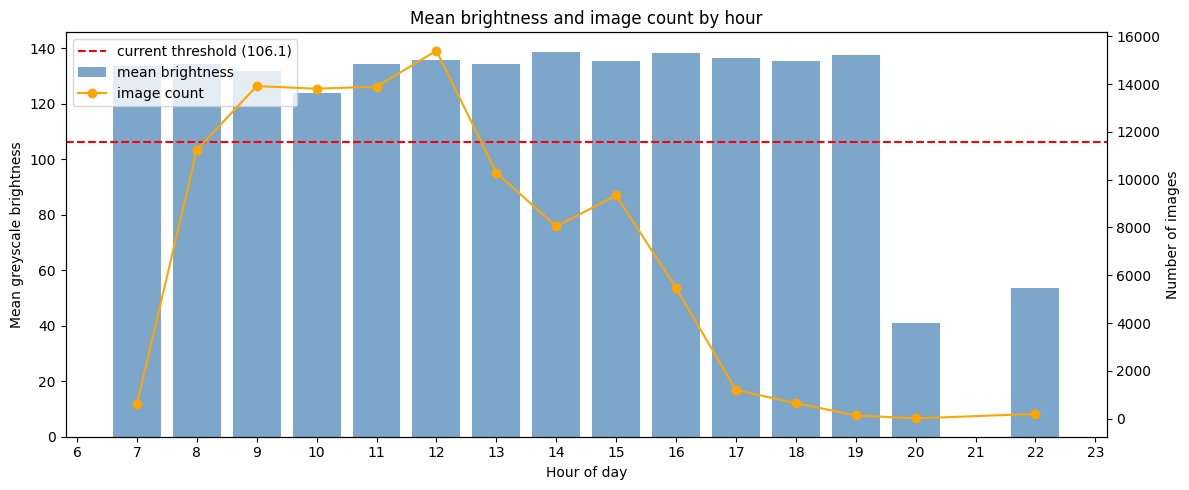

 hour       mean  count
    7 133.504191    606
    8 134.316309  11245
    9 132.012033  13914
   10 124.079703  13804
   11 134.233685  13890
   12 135.882195  15394
   13 134.321077  10292
   14 138.832625   8042
   15 135.370530   9338
   16 138.319697   5472
   17 136.592373   1197
   18 135.517005    651
   19 137.569191    136
   20  41.074286     14
   22  53.451307    199


In [72]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_brightness.csv")

# Mean brightness by hour
by_hour = df.groupby("hour")["grey"].agg(["mean", "count"]).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(by_hour["hour"], by_hour["mean"], color="steelblue", alpha=0.7, label="mean brightness")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Mean greyscale brightness")
ax1.axhline(106.1, color="red", linestyle="--", label="current threshold (106.1)")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(by_hour["hour"], by_hour["count"], color="orange", marker="o", label="image count")
ax2.set_ylabel("Number of images")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Mean brightness and image count by hour")
plt.tight_layout()
plt.show()

print(by_hour.to_string(index=False))

In [41]:
df_eve = df[df["period"] == "evening"]
df_eve["hour"].value_counts().sort_index()
print(f"\nTotal: {len(df_eve)} images")



Total: 349 images


In [42]:
df = pd.read_csv("/Users/mariasilva/data/urban-mosaic/washington-square.csv")
print(df["image"].iloc[0])

0/20160628/79ddade2485edbde/cds-79ddade2485edbde-20160628-0959.raw/3/dr5rsnqv7syb-dr5rsnqv42h2-cds-79ddade2485edbde-20160628-0959-19.jpg


### Identify Evening Images with Pixel Brightness

In [20]:
copied = 0
missing = 0

with open(CSV_PATH) as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["period"] != "night":
            continue
        src = BASE / row["image"]
        if not src.exists():
            missing += 1
            continue
        dst = OUT_DIR / src.name
        shutil.copy2(src, dst)
        copied += 1

print(f"Copied {copied} evening images to '{OUT_DIR}/'  ({missing} missing)")


Copied 0 evening images to 'night/'  (0 missing)


In [16]:
results = []

for img_path in sorted(OUT_DIR.glob("*.jpg")):
    img = Image.open(img_path).convert("L")   # grayscale
    brightness = np.array(img).mean()
    results.append((img_path.name, brightness))

results.sort(key=lambda x: x[1])

print(f"\nBrightness range: {results[0][1]:.1f} – {results[-1][1]:.1f}  (0=black, 255=white)")
print("\nDarkest 5:")
for name, b in results[:5]:
    print(f"  {b:5.1f}  {name}")
print("\nBrightest 5:")
for name, b in results[-5:]:
    print(f"  {b:5.1f}  {name}")


Brightness range: 1.7 – 198.5  (0=black, 255=white)

Darkest 5:
    1.7  dr5rsqb1q2z5-dr5rsqb1rp4e-cds-bd209a4b83760d6b-20160929-2252-1.jpg
    4.1  dr5rsqb1tw1f-dr5rsqb1tkwq-cds-79ddade2485edbde-20160929-2252-1.jpg
   11.5  dr5rsp7n1kgr-dr5rsp7n1t60-cds-79ddade2485edbde-20160929-2242-74.jpg
   15.3  dr5rsp7bcte0-dr5rsp7b2q2s-cds-79ddade2485edbde-20160929-2242-93.jpg
   16.2  dr5rsphpnbcp-dr5rsphnyw7p-cds-bd209a4b83760d6b-20160929-2242-95.jpg

Brightest 5:
  174.3  dr5rspqjpvm8-dr5rspqm8brk-cds-b6d8aab376c7ce54-20160728-1913-147.jpg
  174.6  dr5rspp33e3e-dr5rspp30gsq-cds-b6d8aab376c7ce54-20160728-1913-102.jpg
  183.7  dr5rspp2tpcs-dr5rspp2syj6-cds-b6d8aab376c7ce54-20160728-1913-99.jpg
  190.4  dr5rspphptng-dr5rspphpq8v-cds-63fa6a79d3217a87-20160728-1912-129.jpg
  198.5  dr5rsnzz1fpu-dr5rsnzz684c-cds-b6d8aab376c7ce54-20160728-1913-94.jpg


In [17]:
with open("evening_brightness.csv", "w", newline="") as f:
    w = _csv.writer(f)
    w.writerow(["filename", "mean_brightness"])
    w.writerows(results)
print("\nSaved brightness scores to evening_brightness.csv")


Saved brightness scores to evening_brightness.csv


In [18]:
rows_html = ""
for name, b in results:
    img_src = f"evening/{name}"
    rows_html += f"""
    <div class="card">
      <img src="{img_src}" loading="lazy">
      <div class="score">{b:.1f}</div>
    </div>"""

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Evening image brightness</title>
<style>
  body {{ font-family: sans-serif; background: #111; color: #eee; padding: 16px; }}
  h2 {{ margin-bottom: 4px; }}
  p  {{ margin-top: 0; color: #aaa; font-size: 13px; }}
  .grid {{ display: flex; flex-wrap: wrap; gap: 10px; }}
  .card {{ width: 220px; background: #222; border-radius: 6px; overflow: hidden; }}
  .card img {{ width: 100%; display: block; }}
  .score {{ text-align: center; padding: 6px; font-size: 14px; font-weight: bold; }}
</style>
</head>
<body>
<h2>Evening images — sorted darkest to brightest (mean pixel brightness 0–255)</h2>
<p>Scroll through and decide where the cutoff between nighttime and still-daytime should be.</p>
<div class="grid">{rows_html}
</div>
</body>
</html>"""

with open("evening_viewer.html", "w") as f:
    f.write(html)
print("Saved evening_viewer.html — open in a browser to pick your threshold")


Saved evening_viewer.html — open in a browser to pick your threshold


### Grounding Dino 